# Home Credit Default Risk
### Author: Siqi Wang
### Dataset: Home Credit Group (Kaggle)
### Goal: Predict default risk using demographic, financial, and behavioral features.
### Date: October 2025

## 1. Introduction

Many people struggle to get loans due to insufficient or non-existent credit histories. And, unfortunately, this population is often taken advantage of by untrustworthy lenders.

Home Credit Group

Home Credit strives to broaden financial inclusion for the unbanked population by providing a positive and safe borrowing experience. In order to make sure this underserved population has a positive loan experience, Home Credit makes use of a variety of alternative data--including telco and transactional information--to predict their clients' repayment abilities.

While Home Credit is currently using various statistical and machine learning methods to make these predictions, they're challenging Kagglers to help them unlock the full potential of their data. Doing so will ensure that clients capable of repayment are not rejected and that loans are given with a principal, maturity, and repayment calendar that will empower their clients to be successful.

https://www.kaggle.com/c/home-credit-default-risk/

## 2. Data Loading and Overview

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
pd.set_option('display.max_columns', None)

### app_train only

In [2]:
app_train = pd.read_csv("./home-credit-default-risk/application_train.csv")
app_test = pd.read_csv("./home-credit-default-risk/application_test.csv")

print(app_train.shape, app_test.shape)
app_train.head()

(307511, 122) (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

### table-aggregation

In [4]:
app_train = pd.read_csv("./home-credit-default-risk/application_train.csv")
app_test = pd.read_csv("./home-credit-default-risk/application_test.csv")
bureau = pd.read_csv("./home-credit-default-risk/bureau.csv")
bureau_balance = pd.read_csv("./home-credit-default-risk/bureau_balance.csv")
prev_app = pd.read_csv("./home-credit-default-risk/previous_application.csv")
installments = pd.read_csv("./home-credit-default-risk/installments_payments.csv")
credit_card = pd.read_csv("./home-credit-default-risk/credit_card_balance.csv")
pos_cash = pd.read_csv("./home-credit-default-risk/POS_CASH_balance.csv")

print(app_train.shape, app_test.shape)
app_train.head()

(307511, 122) (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
import numpy as np
import pandas as pd

def safe_div(a, b):
    out = np.divide(a, b, out=np.zeros_like(a, dtype=float), where=(b!=0))
    return out

# --- BUREAU + BUREAU_BALANCE ---
# 1) bureau 基础聚合 + 计数
buro = bureau.copy()
buro['IS_ACTIVE'] = (buro['CREDIT_ACTIVE'] == 'Active').astype('int8')
buro['IS_CLOSED'] = (buro['CREDIT_ACTIVE'] == 'Closed').astype('int8')

buro_agg = buro.groupby('SK_ID_CURR').agg(
    BURO_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BURO_DAYS_CREDIT_MAX=('DAYS_CREDIT', 'max'),
    BURO_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BURO_AMT_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
    BURO_AMT_CREDIT_SUM_SUM=('AMT_CREDIT_SUM', 'sum'),
    BURO_AMT_CREDIT_SUM_MAX=('AMT_CREDIT_SUM', 'max'),
    BURO_AMT_CREDIT_SUM_DEBT_MEAN=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BURO_AMT_CREDIT_SUM_DEBT_SUM=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BURO_CREDIT_DAY_OVERDUE_MEAN=('CREDIT_DAY_OVERDUE','mean'),
    BURO_CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE','max'),
    BURO_CREDIT_DAY_OVERDUE_SUM=('CREDIT_DAY_OVERDUE','sum'),
    BURO_N_LOANS=('SK_ID_BUREAU','count'),
    BURO_N_ACTIVE=('IS_ACTIVE','sum'),
    BURO_N_CLOSED=('IS_CLOSED','sum')
).reset_index()

# 2) bureau_balance：状态占比 + “最近值” + “样本数”
bb = bureau_balance[['SK_ID_BUREAU','MONTHS_BALANCE','STATUS']].copy()
# 状态 one-hot 占比（对每个 SK_ID_BUREAU）
bb_stat = (bb
    .pivot_table(index='SK_ID_BUREAU', columns='STATUS', values='MONTHS_BALANCE', aggfunc='count')
    .fillna(0))
bb_stat = bb_stat.div(bb_stat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
bb_stat.columns = [f'BB_PCT_STATUS_{c}' for c in bb_stat.columns]
bb_cnt = bb.groupby('SK_ID_BUREAU').size().rename('BB_N_ROWS')

# 最近月份（最大 MONTHS_BALANCE）的状态是否逾期（>0）
idx_recent = bb.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].idxmax()
bb_recent = bb.loc[idx_recent, ['SK_ID_BUREAU','STATUS']].copy()
bb_recent['BB_RECENT_DPD_FLAG'] = bb_recent['STATUS'].isin(['1','2','3','4','5']).astype('int8')
bb_recent = bb_recent.drop(columns='STATUS').set_index('SK_ID_BUREAU')

bb_feat = (pd.concat([bb_stat, bb_cnt, bb_recent], axis=1)
           .reset_index())

# 汇回到 bureau，再到客户
buro_min = buro[['SK_ID_BUREAU','SK_ID_CURR']].copy()
bb_join = buro_min.merge(bb_feat, on='SK_ID_BUREAU', how='left')\
                  .drop(columns='SK_ID_BUREAU')
bb_agg = bb_join.groupby('SK_ID_CURR').agg(['mean','max','sum'])
bb_agg.columns = ['BB_' + c[0] + '_' + c[1].upper() for c in bb_agg.columns]
bb_agg = bb_agg.reset_index()

# --- INSTALLMENTS（分期） ---
ip = installments[['SK_ID_CURR','DAYS_INSTALMENT','DAYS_ENTRY_PAYMENT',
                   'AMT_INSTALMENT','AMT_PAYMENT']].copy()
ip['DPD'] = (ip['DAYS_ENTRY_PAYMENT'] - ip['DAYS_INSTALMENT']).clip(lower=0)
ip['DBD'] = (ip['DAYS_INSTALMENT'] - ip['DAYS_ENTRY_PAYMENT']).clip(lower=0)
ip['PAY_RATIO'] = safe_div(ip['AMT_PAYMENT'].values, ip['AMT_INSTALMENT'].replace(0, np.nan).values)

ip_agg = ip.groupby('SK_ID_CURR').agg(
    IP_DPD_MEAN=('DPD','mean'),
    IP_DPD_MAX=('DPD','max'),
    IP_DPD_SUM=('DPD','sum'),
    IP_DBD_MEAN=('DBD','mean'),
    IP_DBD_MAX=('DBD','max'),
    IP_DBD_SUM=('DBD','sum'),
    IP_PAY_RATIO_MEAN=('PAY_RATIO','mean'),
    IP_PAY_RATIO_MAX=('PAY_RATIO','max'),
    IP_N_PAYMENTS=('DPD','size'),
    IP_OVERDUE_RATE=('DPD', lambda s: (s>0).mean())
).reset_index()

# --- PREVIOUS APPLICATION（历史申请） ---
pa = prev_app[['SK_ID_CURR','NAME_CONTRACT_STATUS','AMT_CREDIT','AMT_ANNUITY',
               'DAYS_DECISION','CNT_PAYMENT','DAYS_FIRST_DRAWING','DAYS_FIRST_DUE',
               'DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']].copy()

pa = pa.replace({'DAYS_FIRST_DRAWING': {365243: np.nan},
                 'DAYS_FIRST_DUE': {365243: np.nan},
                 'DAYS_LAST_DUE_1ST_VERSION': {365243: np.nan},
                 'DAYS_LAST_DUE': {365243: np.nan},
                 'DAYS_TERMINATION': {365243: np.nan}})

pa['IS_APPROVED'] = (pa['NAME_CONTRACT_STATUS']=='Approved').astype('int8')
pa['IS_REFUSED']  = (pa['NAME_CONTRACT_STATUS']=='Refused').astype('int8')

g = pa.groupby('SK_ID_CURR')
pa_agg = pd.concat([
    g['AMT_CREDIT'].agg(['mean','max','min']).add_prefix('PA_CREDIT_'),
    g['AMT_ANNUITY'].agg(['mean','max']).add_prefix('PA_ANNUITY_'),
    g['CNT_PAYMENT'].agg(['mean','max']).add_prefix('PA_CNTPAY_'),
    g['IS_APPROVED'].mean().rename('PA_APPROVED_RATE'),
    g['IS_REFUSED'].mean().rename('PA_REFUSED_RATE'),
    g['DAYS_DECISION'].agg(['mean','min']).add_prefix('PA_DECISION_'),
    g['DAYS_DECISION'].min().rename('PA_LAST_DECISION_DAYS')  # 最近期（最接近0，数值最小）
], axis=1).reset_index()

# --- CREDIT CARD（信用卡） ---
cc = credit_card[['SK_ID_CURR','MONTHS_BALANCE','AMT_BALANCE',
                  'AMT_CREDIT_LIMIT_ACTUAL','AMT_DRAWINGS_CURRENT',
                  'AMT_PAYMENT_TOTAL_CURRENT','SK_DPD']].copy()
cc['UTIL'] = safe_div(cc['AMT_BALANCE'].values, (cc['AMT_CREDIT_LIMIT_ACTUAL'].values + 1e-6))

def recent_mean(df, n, key, col, name):
    return (df[df['MONTHS_BALANCE']>=-n]
            .groupby(key)[col].mean().rename(name).reset_index())

cc_agg = cc.groupby('SK_ID_CURR').agg(
    CC_BAL_MEAN=('AMT_BALANCE','mean'),
    CC_BAL_MAX=('AMT_BALANCE','max'),
    CC_LIMIT_MEAN=('AMT_CREDIT_LIMIT_ACTUAL','mean'),
    CC_LIMIT_MAX=('AMT_CREDIT_LIMIT_ACTUAL','max'),
    CC_DRAW_MEAN=('AMT_DRAWINGS_CURRENT','mean'),
    CC_DRAW_SUM=('AMT_DRAWINGS_CURRENT','sum'),
    CC_PAY_MEAN=('AMT_PAYMENT_TOTAL_CURRENT','mean'),
    CC_PAY_SUM=('AMT_PAYMENT_TOTAL_CURRENT','sum'),
    CC_DPD_MEAN=('SK_DPD','mean'),
    CC_DPD_MAX=('SK_DPD','max'),
    CC_N_ROWS=('SK_DPD','size')
).reset_index()
cc_agg['CC_UTILIZATION'] = safe_div(cc_agg['CC_BAL_MEAN'].values, (cc_agg['CC_LIMIT_MEAN'].values + 1e-6))

# 最近窗口
for n in (3,6,12):
    cc_agg = cc_agg.merge(recent_mean(cc, n, 'SK_ID_CURR','UTIL', f'CC_UTIL_{n}M'), on='SK_ID_CURR', how='left')
    cc_agg = cc_agg.merge(recent_mean(cc, n, 'SK_ID_CURR','SK_DPD', f'CC_DPD_{n}M'), on='SK_ID_CURR', how='left')

# --- POS_CASH ---
pos = pos_cash[['SK_ID_CURR','MONTHS_BALANCE','CNT_INSTALMENT_FUTURE','SK_DPD']].copy()
pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_MONTHS_MAX=('MONTHS_BALANCE','max'),
    POS_MONTHS_MIN=('MONTHS_BALANCE','min'),
    POS_FUTURE_MEAN=('CNT_INSTALMENT_FUTURE','mean'),
    POS_FUTURE_MAX=('CNT_INSTALMENT_FUTURE','max'),
    POS_DPD_MEAN=('SK_DPD','mean'),
    POS_DPD_MAX=('SK_DPD','max'),
    POS_OVERDUE_RATE=('SK_DPD', lambda s: (s>0).mean()),
    POS_N_ROWS=('SK_DPD','size')
).reset_index()

def recent_val(df, n, key, col, name):
    recent = df[df['MONTHS_BALANCE']>=-n]
    idx = recent.groupby(key)['MONTHS_BALANCE'].idxmax()
    return recent.loc[idx, [key, col]].rename(columns={col: name})

for n in (3,6):
    pos_agg = pos_agg.merge(recent_mean(pos, n, 'SK_ID_CURR','CNT_INSTALMENT_FUTURE', f'POS_FUTURE_{n}M'), on='SK_ID_CURR', how='left')
    tmp_last = recent_val(pos, n, 'SK_ID_CURR','SK_DPD', f'POS_DPD_LAST_{n}M')
    pos_agg = pos_agg.merge(tmp_last, on='SK_ID_CURR', how='left')

# === 一次性 merge 到 app ===
def merge_all(base):
    out = (base
        .merge(buro_agg, on='SK_ID_CURR', how='left')
        .merge(bb_agg,   on='SK_ID_CURR', how='left')
        .merge(ip_agg,   on='SK_ID_CURR', how='left')
        .merge(pa_agg,   on='SK_ID_CURR', how='left')
        .merge(cc_agg,   on='SK_ID_CURR', how='left')
        .merge(pos_agg,  on='SK_ID_CURR', how='left'))
    return out

app_train = merge_all(app_train)
app_test  = merge_all(app_test)

# 全量填 0（树模型安全），或者后面再用 train 中位数统一填充
fill_cols = app_train.columns.difference(['TARGET','SK_ID_CURR'])
app_train[fill_cols] = app_train[fill_cols].fillna(0)
app_test[fill_cols]  = app_test[fill_cols].fillna(0)


## 3. Data Cleaning

In [6]:
import numpy as np

def safe_div(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.zeros_like(num, dtype=float)
    np.divide(num, den, out=out, where=(den != 0) & np.isfinite(den))
    return out

def add_app_features(df):
    # 把 XNA 当作 0
    df['CODE_GENDER'] = df['CODE_GENDER'].replace('XNA', np.nan)

    # 统一处理 DAYS_EMPLOYED 的哨兵
    df['DAYS_EMPLOYED_CLEAN'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    # 比例特征：使用安全除法
    df['INCOME_CREDIT_RATIO']  = safe_div(df['AMT_INCOME_TOTAL'], df['AMT_CREDIT'])
    df['ANNUITY_INCOME_RATIO'] = safe_div(df['AMT_ANNUITY'], df['AMT_INCOME_TOTAL'])

    # 年龄/工龄（年）
    df['AGE']            = -df['DAYS_BIRTH'] / 365.0
    df['EMPLOYED_YEARS'] = -df['DAYS_EMPLOYED_CLEAN'] / 365.0

    # （可选）加几个常用稳健特征
    df['CREDIT_TERM'] = safe_div(df['AMT_ANNUITY'], df['AMT_CREDIT'])              # 还款额/额度 ~ 期限 proxy
    df['PAYMENT_RATE'] = safe_div(df['AMT_ANNUITY'], df['AMT_CREDIT'])             # 与上等价，后续可二选一
    df['INCOME_PER_PERSON'] = safe_div(df['AMT_INCOME_TOTAL'], (1 + df['CNT_FAM_MEMBERS']))
    df['INCOME_PER_CHILD']  = safe_div(df['AMT_INCOME_TOTAL'], (1 + df['CNT_CHILDREN']))

    # （可选）对数前裁剪，防负数/inf
    df['INCOME_CREDIT_RATIO_LOG'] = np.log1p(np.clip(df['INCOME_CREDIT_RATIO'], 0, None))
    return df

app_train = add_app_features(app_train.copy())
app_test  = add_app_features(app_test.copy())

# 统一缺失填充（树模型直接 0 一般安全；更严谨可用 train 中位数填 test）
fill_cols = [c for c in app_train.columns if c not in ['TARGET','SK_ID_CURR']]
app_train[fill_cols] = app_train[fill_cols].fillna(0)
app_test[fill_cols]  = app_test[fill_cols].fillna(0)


## 4. Feature Engineering

### Poly terms

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

# 1) 选择底层列
poly_input_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS']

# 用 AGE_YEARS（正值，单位：年）
for df in [app_train, app_test]:
    if 'AGE_YEARS' not in df.columns:
        df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365.0

# 2) y 备份
y = app_train['TARGET'].copy()

# 3) 仅对 poly 输入做填补（用 train 的统计量）
app_train_sub = app_train[poly_input_cols].copy()
app_test_sub  = app_test[poly_input_cols].copy()

train_median = app_train_sub.median()
app_train_sub = app_train_sub.fillna(train_median)
app_test_sub  = app_test_sub.fillna(train_median)  # 注意：用 train 统计量

# 4) 多项式交互（仅交互，degree=2）
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly.fit(app_train_sub)

train_poly = poly.transform(app_train_sub)
test_poly  = poly.transform(app_test_sub)

poly_cols = [f'POLY__{c}' for c in poly.get_feature_names_out(poly_input_cols)]

poly_train_df = pd.DataFrame(train_poly, columns=poly_cols, index=app_train.index)
poly_test_df  = pd.DataFrame(test_poly,  columns=poly_cols, index=app_test.index)

# 5) 合并回原表
app_train_poly = pd.concat([app_train, poly_train_df], axis=1)
app_test_poly  = pd.concat([app_test,  poly_test_df],  axis=1)

# 6) 列对齐 —— 用“左对齐”保留所有训练特征；test 中缺失列补 0
train_no_target = app_train_poly.drop(columns=['TARGET'])
train_no_target, app_test_poly = train_no_target.align(
    app_test_poly, join='left', axis=1, fill_value=0
)

# 把 TARGET 加回
app_train_poly_aligned = pd.concat([train_no_target, y], axis=1)

# 可选：确保 ID/行数完整
assert 'SK_ID_CURR' in app_train_poly_aligned.columns
assert 'SK_ID_CURR' in app_test_poly.columns
assert app_test_poly['SK_ID_CURR'].nunique() == app_test['SK_ID_CURR'].nunique()

# 如果后续模型用 app_train_poly_aligned
app_test = app_test_poly 
app_train = app_train_poly_aligned

C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_43884\2320009468.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365.0
C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_43884\2320009468.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365.0


In [8]:
# 1) 训练特征集合（以训练集为准）
features = [c for c in app_train.columns if c not in ['TARGET','SK_ID_CURR']]
# features = [c for c in app_train_poly_aligned.columns if c not in ['TARGET','SK_ID_CURR']]

# 2) 训练集设计矩阵
X = app_train[features].copy()

# 3) 测试集严格按训练列 reindex（缺的列会自动补 NaN；多余列被丢弃）
app_test_features = app_test.reindex(columns=features)

# 4) 缺失填充：
#    - 先用 train 的列中位数去填 test（推荐）
#    - train 也可以统一填 0（或中位数），保证和 test 一致
# 只对数值列取中位数
train_median = X.select_dtypes(include=[np.number]).median()

# 然后用中位数去填充，只在数值列上生效
X = X.fillna(train_median)
app_test_features = app_test_features.fillna(train_median)

# 5) 清理 inf
X = X.replace([np.inf, -np.inf], 0)
app_test_features = app_test_features.replace([np.inf, -np.inf], 0)

# 6) 目标
y = app_train['TARGET'].astype(int)


In [9]:
# 检查并转换类别特征为数值类型
def convert_categorical_features(df):
    # 将分类变量映射为数值型
    df['NAME_CONTRACT_TYPE'] = df['NAME_CONTRACT_TYPE'].map({'Cash loans': 0, 'Revolving loans': 1}).astype(float)
    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1, 'XNA': 0}).astype(float)
    df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map({'N': 0, 'Y': 1}).astype(float)
    df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map({'N': 0, 'Y': 1}).astype(float)
    df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].map({'Unaccompanied': 0, 'Missing': 0, 'Other_A': 0, 'Other_B': 0, 'Spouse, partner': 1, 'Family': 1, 'Children': 1, 'Group of people': 1}).astype(float)
    df['NAME_INCOME_TYPE'] = df['NAME_INCOME_TYPE'].map(lambda v: 1.0 if v in {'Working', 'State servant', 'Commercial associate', 'Businessman', 'Pensioner'} else 0.0).astype(float)
    df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map({'Lower secondary': 0, 'Secondary / secondary special': 1, 'Incomplete higher': 2, 'Higher education': 3, 'Academic degree': 4}).astype(float)
    df['NAME_FAMILY_STATUS'] = df['NAME_FAMILY_STATUS'].map({'Single / not married': 0, 'Unknown': 0, 'Widow': 1, 'Separated': 1, 'Married': 2, 'Civil marriage': 2}).astype(float)
    df['NAME_HOUSING_TYPE'] = df['NAME_HOUSING_TYPE'].map({'House / apartment': 1, 'Co-op apartment': 1, 'With parents': 0, 'Rented apartment': 0, 'Municipal apartment': 0, 'Office apartment': 0}).astype(float)
    df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].map({'Managers': 2, 'Accountants': 2, 'Core staff': 2, 'High skill tech staff': 2, 'IT staff': 2, 'HR staff': 2, 'Medicine staff': 2, 'Sales staff': 1, 'Drivers': 1, 'Realty agents': 1, 'Secretaries': 1, 'Laborers': 0, 'Low-skill Laborers': 0, 'Cleaning staff': 0, 'Cooking staff': 0, 'Private service staff': 0, 'Waiters/barmen staff': 0, 'Security staff': 0, 'Missing': 0}).astype(float)
    
    def map_org_type(x):
        if x in {'Government', 'School', 'University', 'Security Ministries', 'Police', 'Military', 'Kindergarten'}: return 3
        if x in {'Bank', 'Insurance', 'Telecom', 'Electricity', 'Medicine'}: return 3
        if str(x).startswith(('Industry', 'Trade', 'Construction')): return 2
        if x in {'Business Entity Type 1', 'Business Entity Type 2', 'Business Entity Type 3', 'Services', 'Realtor', 'Restaurant', 'Hotel', 'Transport: type 1', 'Transport: type 2', 'Transport: type 3', 'Transport: type 4', 'Self-employed'}: return 1
        return 0
    df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].apply(map_org_type).astype(float)
    
    df['WEEKDAY_APPR_PROCESS_START'] = df['WEEKDAY_APPR_PROCESS_START'].map(lambda x: 1.0 if x in ['SATURDAY', 'SUNDAY'] else 0.0)
    df['FONDKAPREMONT_MODE'] = df['FONDKAPREMONT_MODE'].replace(0, 'Missing').map(lambda x: 1.0 if x in ['reg oper account', 'org spec account', 'reg oper spec account'] else 0.0)
    df['HOUSETYPE_MODE'] = df['HOUSETYPE_MODE'].replace(0, 'Missing').map({'terraced house': 1, 'block of flats': 1, 'specific housing': 0, 'Missing': 0}).astype(float)
    df['WALLSMATERIAL_MODE'] = df['WALLSMATERIAL_MODE'].replace(0, 'Missing').map(lambda x: 1.0 if x in ['Stone, brick', 'Block', 'Monolithic'] else 0.0)
    df['EMERGENCYSTATE_MODE'] = df['EMERGENCYSTATE_MODE'].replace(0, 'Missing').map({'No': 0.0, 'Missing': 0.0, 'Yes': 1.0})
    
    return df

# 处理 train 和 test
X = convert_categorical_features(app_train[features])
T = convert_categorical_features(app_test_features)

# 填充缺失值：用训练集的中位数填充
train_median = X.select_dtypes(include=[np.number]).median()
X = X.fillna(train_median)
T = T.fillna(train_median)

# 目标
y = app_train['TARGET'].astype(int)


C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_43884\4209581058.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NAME_CONTRACT_TYPE'] = df['NAME_CONTRACT_TYPE'].map({'Cash loans': 0, 'Revolving loans': 1}).astype(float)
C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_43884\4209581058.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1, 'XNA': 0}).astype(float)
C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_43884\4209581058.py:6: SettingWithCopy

In [10]:
# 仅对数值列计算中位数
train_median = X.select_dtypes(include=[np.number]).median()

# 用训练集中位数填充测试集
T.fillna(train_median, inplace=True)

# 检查测试集中是否缺列
missing_columns = set(X.columns) - set(T.columns)
extra_columns = set(T.columns) - set(X.columns)
print(f"Missing in Test: {missing_columns}")
print(f"Extra in Test: {extra_columns}")

# 最安全的做法：对齐列顺序
T = T.reindex(columns=X.columns)


❌ Missing in Test: set()
⚠️ Extra in Test: set()


## 5. Model Training and Validation

In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

params = {
    "objective": "binary",
    "n_estimators": 5000,
    "learning_rate": 0.03,
    "max_depth": 15,
    "num_leaves": 64,
    "feature_fraction": 0.7,      # = colsample_bytree
    "bagging_fraction": 0.75,
    "bagging_freq": 3,
    "max_bin": 400,
    "reg_alpha": 1.0,             # L1
    "reg_lambda": 5.0,            # L2
    "min_child_samples": 120,
    "min_child_weight": 6,
    "n_jobs": -1,
    "random_state": 42,
    "verbose": -1
}


# 构造 LightGBM 数据集
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_valid, label=y_valid)

# 训练模型 + 早停
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    num_boost_round=2000,      
    callbacks=[lgb.early_stopping(200), lgb.log_evaluation(100)] 
)

# 用最佳轮数预测
y_pred = model.predict(X_valid, num_iteration=model.best_iteration)
auc = roc_auc_score(y_valid, y_pred)
print(f"Validation AUC: {auc:.4f}")



E:\ProgramData\Anaconda3\envs\torch\lib\site-packages\lightgbm\engine.py:172: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 200 rounds
[100]	training's binary_logloss: 0.235101	valid_1's binary_logloss: 0.242414
[200]	training's binary_logloss: 0.223761	valid_1's binary_logloss: 0.238374
[300]	training's binary_logloss: 0.215825	valid_1's binary_logloss: 0.237055
[400]	training's binary_logloss: 0.209057	valid_1's binary_logloss: 0.236502
[500]	training's binary_logloss: 0.20304	valid_1's binary_logloss: 0.236266
[600]	training's binary_logloss: 0.197363	valid_1's binary_logloss: 0.236161
[700]	training's binary_logloss: 0.19207	valid_1's binary_logloss: 0.236305
[800]	training's binary_logloss: 0.187066	valid_1's binary_logloss: 0.236336
Early stopping, best iteration is:
[608]	training's binary_logloss: 0.196938	valid_1's binary_logloss: 0.236159
Validation AUC: 0.7871


In [13]:
import pandas as pd
import lightgbm as lgb

def lgb_importance_df(model, importance_type="gain"):
    """
    支持两种模型：
      - Booster（lgb.train 或 clf.booster_）
      - LGBMClassifier / LGBMRegressor（sklearn API）
    importance_type: "split" 或 "gain"
    """
    # 拿到 booster
    booster = model.booster_ if hasattr(model, "booster_") else model
    if not isinstance(booster, lgb.Booster):
        raise TypeError("model 既不是 Booster 也不是已fit的 LGBMClassifier/LGBMRegressor")

    names = booster.feature_name()
    imps  = booster.feature_importance(importance_type=importance_type)
    df = pd.DataFrame({"feature": names, "importance": imps})
    return df.sort_values("importance", ascending=False).reset_index(drop=True)


imp_df = lgb_importance_df(model, importance_type="gain")  # 或 "split"
print(imp_df.head(10)) 

# 取“倒数”最不重要的20个特征名
least_20 = imp_df.sort_values("importance", ascending=True).head(20)["feature"].tolist()
print("最不重要的20个特征：", least_20)


                           feature    importance
0  POLY__EXT_SOURCE_2_EXT_SOURCE_3  74718.771474
1     POLY__EXT_SOURCE_2_AGE_YEARS  27728.686646
2                     EXT_SOURCE_3  24329.713428
3                      CREDIT_TERM  18333.120265
4                     EXT_SOURCE_2  15003.122788
5  POLY__EXT_SOURCE_1_EXT_SOURCE_2   9934.678703
6                      AMT_ANNUITY   9580.433332
7                  IP_OVERDUE_RATE   9529.293570
8                  POS_FUTURE_MEAN   8731.500378
9     POLY__EXT_SOURCE_3_AGE_YEARS   8545.513977
最不重要的20个特征： ['FLAG_DOCUMENT_21', 'FLAG_DOCUMENT_15', 'BB_BB_RECENT_DPD_FLAG_SUM', 'BB_BB_PCT_STATUS_3_MAX', 'NAME_INCOME_TYPE', 'FONDKAPREMONT_MODE', 'BURO_CREDIT_DAY_OVERDUE_SUM', 'FLAG_MOBIL', 'FLAG_DOCUMENT_9', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_5']


In [14]:
# 1) 训练一个初始模型 -> 得到 imp_df 和 least_20
# ... imp_df = lgb_importance_df(model, "gain")
# ... least_20 = ...

# 2) 丢列（train/test 同步）
X = X.drop(columns=least_20, errors='ignore')
T = app_test_features.drop(columns=least_20, errors='ignore')

# 3) 列对齐（非常关键，确保列完全一致 + 顺序一致）
T = T.reindex(columns=X.columns)

# 4) 缺失值填充：只对数值列取中位数，用 train 的统计量去填 test
train_median = X.select_dtypes(include=[np.number]).median()
X = X.fillna(train_median)
T = T.fillna(train_median)


In [17]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

params = {
    "objective": "binary",
    "n_estimators": 5000,
    "learning_rate": 0.03,
    "max_depth": 10,
    "num_leaves": 30,
    "feature_fraction": 0.7,
    "bagging_fraction": 0.75,
    "bagging_freq": 3,
    "max_bin": 500,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
    "min_child_samples": 200,
    "min_child_weight": 12,
    "scale_pos_weight":0.1* len(y_train[y_train==0]) / len(y_train[y_train==1]),
    "n_jobs": -1,
    "random_state": 42,
    "verbose": -1,
}

clf = LGBMClassifier(**params)

# 早停 + 记录 AUC
clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_names=['train','valid'],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(200), lgb.log_evaluation(100)]
)



Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.781081	train's binary_logloss: 0.241606	valid's auc: 0.769545	valid's binary_logloss: 0.244403
[200]	train's auc: 0.801501	train's binary_logloss: 0.233544	valid's auc: 0.781212	valid's binary_logloss: 0.239516
[300]	train's auc: 0.814581	train's binary_logloss: 0.228506	valid's auc: 0.786088	valid's binary_logloss: 0.237597
[400]	train's auc: 0.824908	train's binary_logloss: 0.224648	valid's auc: 0.788306	valid's binary_logloss: 0.236819
[500]	train's auc: 0.833932	train's binary_logloss: 0.221294	valid's auc: 0.789242	valid's binary_logloss: 0.236409
[600]	train's auc: 0.841913	train's binary_logloss: 0.218275	valid's auc: 0.790074	valid's binary_logloss: 0.236116
[700]	train's auc: 0.84938	train's binary_logloss: 0.215348	valid's auc: 0.790622	valid's binary_logloss: 0.235908
[800]	train's auc: 0.856349	train's binary_logloss: 0.212581	valid's auc: 0.790578	valid's binary_logloss: 0.235894
[900]	train

LGBMClassifier(bagging_fraction=0.75, bagging_freq=3, feature_fraction=0.7,
               learning_rate=0.03, max_bin=500, max_depth=10,
               min_child_samples=200, min_child_weight=12, n_estimators=5000,
               n_jobs=-1, num_leaves=30, objective='binary', random_state=42,
               reg_alpha=1.0, reg_lambda=5.0,
               scale_pos_weight=1.1387109768378652, verbose=-1)

In [ ]:
y_pred_test = clf.predict_proba(T, num_iteration=model.best_iteration)[:,1]
submission = pd.DataFrame({"SK_ID_CURR": app_test["SK_ID_CURR"], "TARGET": y_pred_test})
# submission.to_csv('/kaggle/working/submission.csv', index=False)
submission

In [18]:
# 用最佳轮数做预测（sklearn 会自动用 best_iteration_）
y_pred_prob = clf.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, y_pred_prob)
print("Validation AUC:", round(auc, 4))
print("Best iteration:", clf.best_iteration_)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 用最佳轮数预测（sklearn 接口自动使用 best_iteration_）
y_pred_prob = clf.predict_proba(X_valid)[:, 1]
y_pred_label = (y_pred_prob >= 0.5).astype(int)

# 各类指标
auc = roc_auc_score(y_valid, y_pred_prob)
acc = accuracy_score(y_valid, y_pred_label)
precision = precision_score(y_valid, y_pred_label)
recall = recall_score(y_valid, y_pred_label)
f1 = f1_score(y_valid, y_pred_label)

print(f"Validation AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Best iteration: {clf.best_iteration_}")

# 打印混淆矩阵或分类报告
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_pred_label))

print("\nClassification Report:")
print(classification_report(y_valid, y_pred_label, target_names=["Non-default", "Default"]))


Validation AUC: 0.7908
Best iteration: 905
Validation AUC: 0.7908
Accuracy: 0.9196
Precision: 0.5162
Recall: 0.0608
F1-score: 0.1088
Best iteration: 905

Confusion Matrix:
[[56255   283]
 [ 4663   302]]

Classification Report:
              precision    recall  f1-score   support

 Non-default       0.92      0.99      0.96     56538
     Default       0.52      0.06      0.11      4965

    accuracy                           0.92     61503
   macro avg       0.72      0.53      0.53     61503
weighted avg       0.89      0.92      0.89     61503



Note: Validation AUC: 0.7583  
This baseline model demonstrates reasonable predictive performance using only features from the application table.  
Further improvement can be achieved by aggregating historical credit records from the auxiliary tables (bureau, previous_application, etc.).

## Confusion Matrix

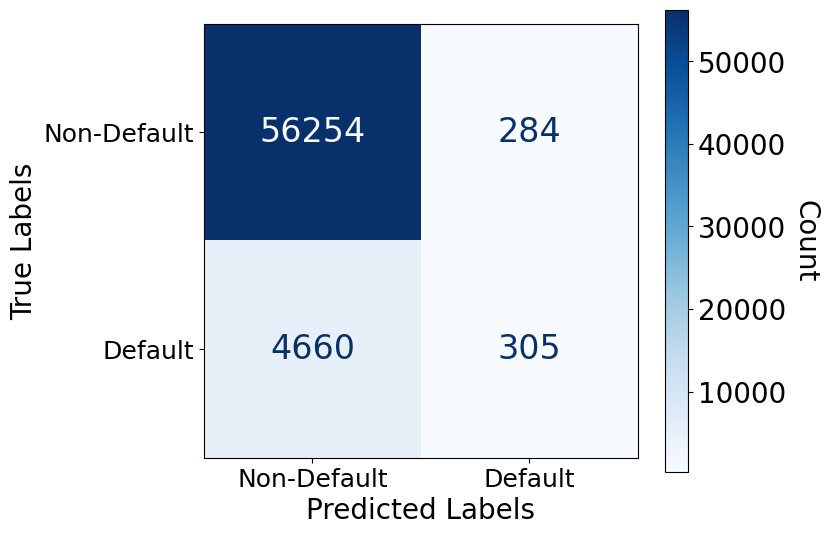

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 计算混淆矩阵
y_pred_prob = clf.predict_proba(X_valid)[:, 1]
y_pred_labels = (y_pred_prob >= 0.5).astype(int)
cm = confusion_matrix(y_valid, y_pred_labels)

# 绘制混淆矩阵
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default', 'Default'])
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)

# 修改矩阵内数字字体大小
for text in ax.texts:
    text.set_fontsize(24)

# 修改坐标轴字体
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlabel('Predicted Labels', fontsize=20)
ax.set_ylabel('True Labels', fontsize=20)

# 修改右侧 colorbar 的字体大小
cbar = ax.get_figure().axes[-1]  # colorbar 在最后一个 axes 中
cbar.tick_params(labelsize=20)   # 调整 colorbar 刻度字体
cbar.set_ylabel('Count', fontsize=20, rotation=270, labelpad=24)  # 加上标签

# 保存图像
# plt.tight_layout()
plt.savefig("confusion_matrix.pdf", bbox_inches='tight', dpi=300)
plt.show()


## 7. Feature Importance and Interpretation

C:\Users\wangsiqi\AppData\Local\Temp\ipykernel_37808\169154457.py:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=12, fontsize=20)


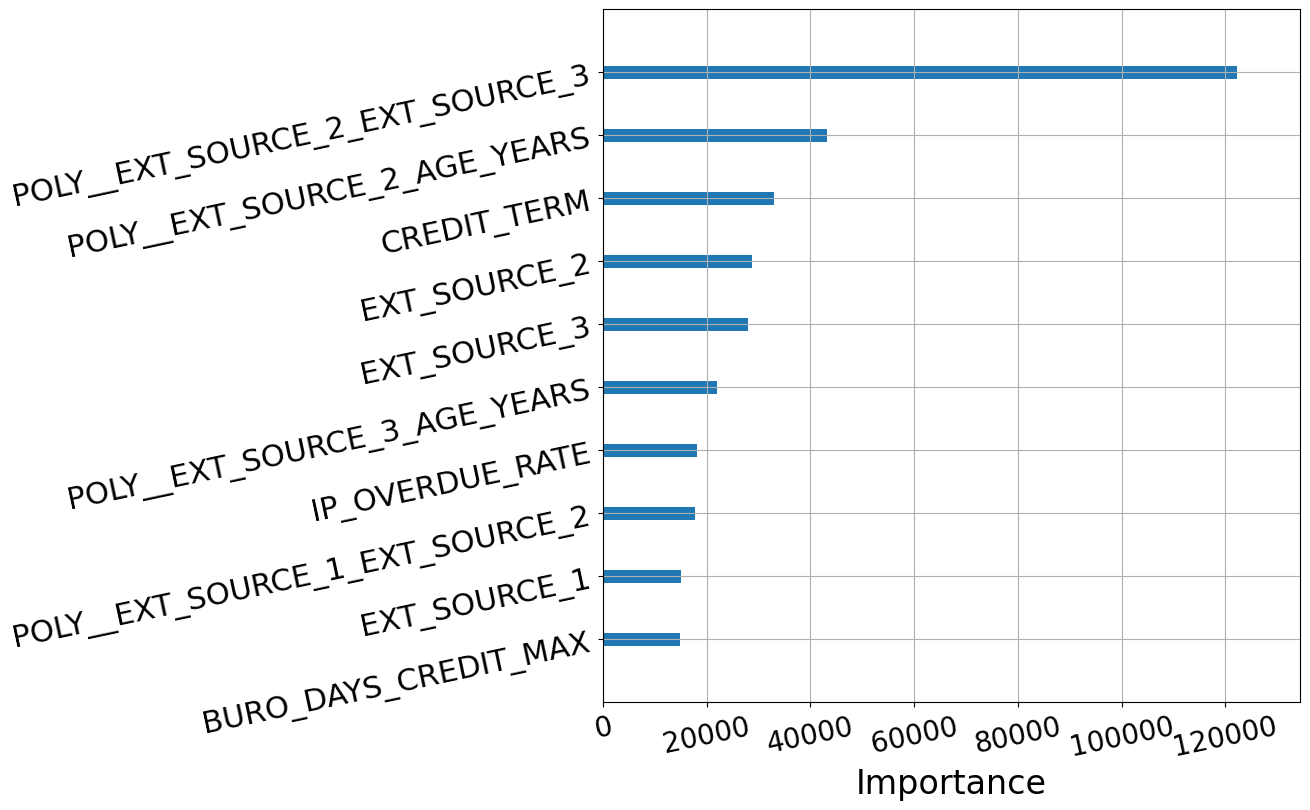

In [34]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# 绘制特征重要性
ax = lgb.plot_importance(clf, max_num_features=10, importance_type='gain', figsize=(9, 9))

# 放大 x, y 轴的 label 和 ticks 字号
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel('Importance', fontsize=24)
ax.set_ylabel('', fontsize=24)

# 旋转 y 轴和 x 轴标签
ax.set_yticklabels(ax.get_yticklabels(), rotation=12, fontsize=22)
ax.set_xticklabels(ax.get_xticklabels(), rotation=12, fontsize=20)

# 去掉标题
ax.set_title('')

# 去掉显示的具体 importance 数值
for text in ax.texts:
    text.set_visible(False)

# 保存图像
# plt.tight_layout()
plt.savefig("feature_importance.pdf", bbox_inches='tight', dpi=300)
plt.show()
